<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">1. Import Libraries</h3>
</div>


In [95]:
import matplotlib.pyplot as plt
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

In [46]:
import warnings

warnings.filterwarnings('ignore')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">2. Import Dataset</h3>
</div>


In [47]:
# Load the dataset
df = pd.read_csv('turnover.csv', encoding='ISO-8859-1')

<div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1); border-left: 5px solid #4CAF50; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h3 style="color: #2c3e50; font-size: 24px; font-weight: bold; margin: 0; padding-bottom: 10px;">3. Exploratory data analysis </h3>
</div>


In [48]:
# View dimension of dataset
df.shape

(1129, 16)

In [49]:
# Preview the dataset
df.head()

,stag,event,gender,age,industry,profession,traffic,coach,head_gender,greywage,way,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,1,m,35.0,Banks,HR,rabrecNErab,no,f,white,bus,6.2,4.1,5.7,7.1,8.3
1,22.965092,1,m,33.0,Banks,HR,empjs,no,m,white,bus,6.2,4.1,5.7,7.1,8.3
2,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,6.2,6.2,2.6,4.8,8.3
3,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,5.4,7.6,4.9,2.5,6.7
4,8.410678,1,m,32.0,Retail,Commercial,youjs,yes,f,white,bus,3.0,4.1,8.0,7.1,3.7


In [50]:
# View column names
col_names = df.columns
print(col_names)

Index(['stag', 'event', 'gender', 'age', 'industry', 'profession', 'traffic',
       'coach', 'head_gender', 'greywage', 'way', 'extraversion', 'independ',
       'selfcontrol', 'anxiety', 'novator'],
      dtype='object')


In [51]:
# View summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stag          1129 non-null   float64
 1   event         1129 non-null   int64  
 2   gender        1129 non-null   object 
 3   age           1129 non-null   float64
 4   industry      1129 non-null   object 
 5   profession    1129 non-null   object 
 6   traffic       1129 non-null   object 
 7   coach         1129 non-null   object 
 8   head_gender   1129 non-null   object 
 9   greywage      1129 non-null   object 
 10  way           1129 non-null   object 
 11  extraversion  1129 non-null   float64
 12  independ      1129 non-null   float64
 13  selfcontrol   1129 non-null   float64
 14  anxiety       1129 non-null   float64
 15  novator       1129 non-null   float64
dtypes: float64(7), int64(1), object(8)
memory usage: 141.3+ KB


In [52]:
# find categorical variables
categorical = [var for var in df.columns if df[var].dtype == 'O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :', categorical)

There are 8 categorical variables

The categorical variables are : ['gender', 'industry', 'profession', 'traffic', 'coach', 'head_gender', 'greywage', 'way']


In [53]:
# view the categorical variables
df[categorical].head()

,gender,industry,profession,traffic,coach,head_gender,greywage,way
0,m,Banks,HR,rabrecNErab,no,f,white,bus
1,m,Banks,HR,empjs,no,m,white,bus
2,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
3,f,PowerGeneration,HR,rabrecNErab,no,m,white,bus
4,m,Retail,Commercial,youjs,yes,f,white,bus


In [54]:
# check missing values in categorical variables
df[categorical].isnull().sum()

gender         0
industry       0
profession     0
traffic        0
coach          0
head_gender    0
greywage       0
way            0
dtype: int64

In [55]:
# view frequency of categorical variables
for var in categorical:
    print(df[var].value_counts())

gender
f    853
m    276
Name: count, dtype: int64
industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64
profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64
traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
K

In [56]:
# view frequency distribution of categorical variables
for var in categorical:
    print(df[var].value_counts() / float(len(df)))

gender
f    0.755536
m    0.244464
Name: count, dtype: float64
industry
Retail             0.255979
manufacture        0.128432
IT                 0.108060
Banks              0.100974
etc                0.083260
Consult            0.065545
State              0.048716
Building           0.036315
PowerGeneration    0.033658
transport          0.033658
Telecom            0.031887
Mining             0.021258
Pharma             0.017715
Agriculture        0.013286
RealEstate         0.011515
 HoReCa            0.009743
Name: count, dtype: float64
profession
HR                     0.670505
IT                     0.065545
Sales                  0.058459
etc                    0.032772
Marketing              0.027458
BusinessDevelopment    0.023915
Consult                0.022143
Commercial             0.020372
manage                 0.019486
Finanñe                0.015058
Engineer               0.013286
Teaching               0.010629
Accounting             0.008857
Law                    0.

In [57]:
# check for cardinality in categorical variables
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

gender  contains  2  labels
industry  contains  16  labels
profession  contains  15  labels
traffic  contains  8  labels
coach  contains  3  labels
head_gender  contains  2  labels
greywage  contains  2  labels
way  contains  3  labels


<div style="background-color: #e8f4f8; padding: 15px 25px; border-radius: 8px; box-shadow: 0 3px 6px rgba(0, 0, 0, 0.1); border-left: 4px solid #3498db; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h4 style="color: #2c3e50; font-size: 20px; font-weight: bold; margin: 0; padding-bottom: 8px;">3.1. Explore problems within categorical variables</h4>
    </div>


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.1. Explore Gender Variable
</h5>
</div>


In [58]:
# print number of labels in Location variable
print('Gender contains', len(df.gender.unique()), 'labels')

Gender contains 2 labels


In [59]:
# check labels in gender variable
df.gender.unique()

array(['m', 'f'], dtype=object)

In [60]:
# check frequency distribution of values in Location variable
df.gender.value_counts()

gender
f    853
m    276
Name: count, dtype: int64

In [61]:
# let's do One Hot Encoding of Location variable
# get k-1 dummy variables after One Hot Encoding
# preview the dataset with head() method

pd.get_dummies(df.gender, drop_first=True).head()

,m
0,True
1,True
2,False
3,False
4,True


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.2. Explore industry Variable
</h5>
</div>



In [62]:
print('Industry contains', len(df.industry.unique()), 'labels')

Industry contains 16 labels


In [63]:
df.industry.unique()

array(['Banks', 'PowerGeneration', 'Retail', 'manufacture', 'Consult',
       'State', 'etc', 'Building', 'IT', ' HoReCa', 'Telecom', 'Pharma',
       'Mining', 'transport', 'Agriculture', 'RealEstate'], dtype=object)

In [64]:
df.industry.value_counts()

industry
Retail             289
manufacture        145
IT                 122
Banks              114
etc                 94
Consult             74
State               55
Building            41
PowerGeneration     38
transport           38
Telecom             36
Mining              24
Pharma              20
Agriculture         15
RealEstate          13
 HoReCa             11
Name: count, dtype: int64

In [65]:
# let's do One Hot Encoding of WindGustDir variable
# get k-1 dummy variables after One Hot Encoding
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.industry, drop_first=True, dummy_na=True).head()

,Agriculture,Banks,Building,Consult,IT,Mining,Pharma,PowerGeneration,RealEstate,Retail,State,Telecom,etc,manufacture,transport,NaN
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


<div style="background-color: #ffffff; padding: 20px 30px; border-radius: 8px; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); border-left: 6px solid #e74c3c; font-family: 'Arial', sans-serif; transition: all 0.3s ease;">
    <h5 style="color: #2c3e50; font-size: 22px; font-weight: bold; margin: 0; padding-bottom: 10px;">3.1.3. Explore profession Variable</h5>
</div>


In [66]:
print('Profession contains', len(df.profession.unique()), 'labels')

Profession contains 15 labels


In [67]:
df.profession.unique()

array(['HR', 'Commercial', 'Marketing', 'etc', 'Sales',
       'BusinessDevelopment', 'Finanñe', 'Teaching', 'manage', 'IT',
       'Law', 'Consult', 'Engineer', 'PR', 'Accounting'], dtype=object)

In [68]:
df.profession.value_counts()

profession
HR                     757
IT                      74
Sales                   66
etc                     37
Marketing               31
BusinessDevelopment     27
Consult                 25
Commercial              23
manage                  22
Finanñe                 17
Engineer                15
Teaching                12
Accounting              10
Law                      7
PR                       6
Name: count, dtype: int64

In [69]:
pd.get_dummies(df.profession, drop_first=True, dummy_na=True).head()

,BusinessDevelopment,Commercial,Consult,Engineer,Finanñe,HR,IT,Law,Marketing,PR,Sales,Teaching,etc,manage,NaN
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


### Explore traffic Variable

In [70]:
print('Traffic contains', len(df.traffic.unique()), 'labels')

Traffic contains 8 labels


In [71]:
df.traffic.unique()

array(['rabrecNErab', 'empjs', 'youjs', 'referal', 'advert', 'KA',
       'recNErab', 'friends'], dtype=object)

In [72]:
df.traffic.value_counts()

traffic
youjs          318
empjs          248
rabrecNErab    211
friends        118
referal         95
KA              67
recNErab        39
advert          33
Name: count, dtype: int64

In [73]:
pd.get_dummies(df.traffic, drop_first=True, dummy_na=True).head()

,advert,empjs,friends,rabrecNErab,recNErab,referal,youjs,NaN
0,False,False,False,True,False,False,False,False
1,False,True,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,True,False


### Explore coach Variable


In [74]:
print('Coach contains', len(df.coach.unique()), 'labels')

Coach contains 3 labels


In [75]:
df.coach.unique()

array(['no', 'yes', 'my head'], dtype=object)

In [76]:
df.coach.value_counts()

coach
no         683
my head    314
yes        132
Name: count, dtype: int64

In [77]:
pd.get_dummies(df.coach, drop_first=True, dummy_na=True).head()

,no,yes,NaN
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


### Explore head gender Variable


In [78]:
print('Head gender contains', len(df.head_gender.unique()), 'labels')


Head gender contains 2 labels


In [80]:
df.head_gender.unique()

array(['f', 'm'], dtype=object)

In [81]:
df.head_gender.value_counts()


head_gender
m    584
f    545
Name: count, dtype: int64

In [82]:
pd.get_dummies(df.head_gender, drop_first=True, dummy_na=True).head()


,m,NaN
0,False,False
1,True,False
2,True,False
3,True,False
4,False,False


### Explore greywage Variable


In [83]:
print('Greywage contains', len(df.greywage.unique()), 'labels')

Greywage contains 2 labels


In [84]:
df.greywage.unique()

array(['white', 'grey'], dtype=object)

In [85]:
df.greywage.value_counts()

greywage
white    1002
grey      127
Name: count, dtype: int64

In [86]:
pd.get_dummies(df.greywage, drop_first=True, dummy_na=True).head()

,white,NaN
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


### Explore way Variable


In [87]:
print('Way contains', len(df.way.unique()), 'labels')

Way contains 3 labels


In [88]:
df.way.unique()

array(['bus', 'car', 'foot'], dtype=object)

In [89]:
df.way.value_counts()

way
bus     681
car     331
foot    117
Name: count, dtype: int64

In [90]:
pd.get_dummies(df.way, drop_first=True, dummy_na=True).head()

,car,foot,NaN
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


### Explore Numerical Variables

In [91]:
# find numerical variables
numerical = [var for var in df.columns if df[var].dtype != 'O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 8 numerical variables

The numerical variables are : ['stag', 'event', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']


In [92]:
# view the numerical variables
df[numerical].head()

,stag,event,age,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,1,35.0,6.2,4.1,5.7,7.1,8.3
1,22.965092,1,33.0,6.2,4.1,5.7,7.1,8.3
2,15.934292,1,35.0,6.2,6.2,2.6,4.8,8.3
3,15.934292,1,35.0,5.4,7.6,4.9,2.5,6.7
4,8.410678,1,32.0,3.0,4.1,8.0,7.1,3.7


In [93]:
# check missing values in numerical variables
df[numerical].isnull().sum()

stag            0
event           0
age             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [97]:
# view summary statistics in numerical variables
print(df[numerical].describe().round(2))

          stag    event      age  extraversion  independ  selfcontrol  \
count  1129.00  1129.00  1129.00       1129.00   1129.00      1129.00   
mean     36.63     0.51    31.07          5.59      5.48         5.60   
std      34.10     0.50     7.00          1.85      1.70         1.98   
min       0.39     0.00    18.00          1.00      1.00         1.00   
25%      11.73     0.00    26.00          4.60      4.10         4.10   
50%      24.34     1.00    30.00          5.40      5.50         5.70   
75%      51.32     1.00    36.00          7.00      6.90         7.20   
max     179.45     1.00    58.00         10.00     10.00        10.00   

       anxiety  novator  
count  1129.00  1129.00  
mean      5.67     5.88  
std       1.71     1.90  
min       1.70     1.00  
25%       4.80     4.40  
50%       5.60     6.00  
75%       7.10     7.50  
max      10.00    10.00  


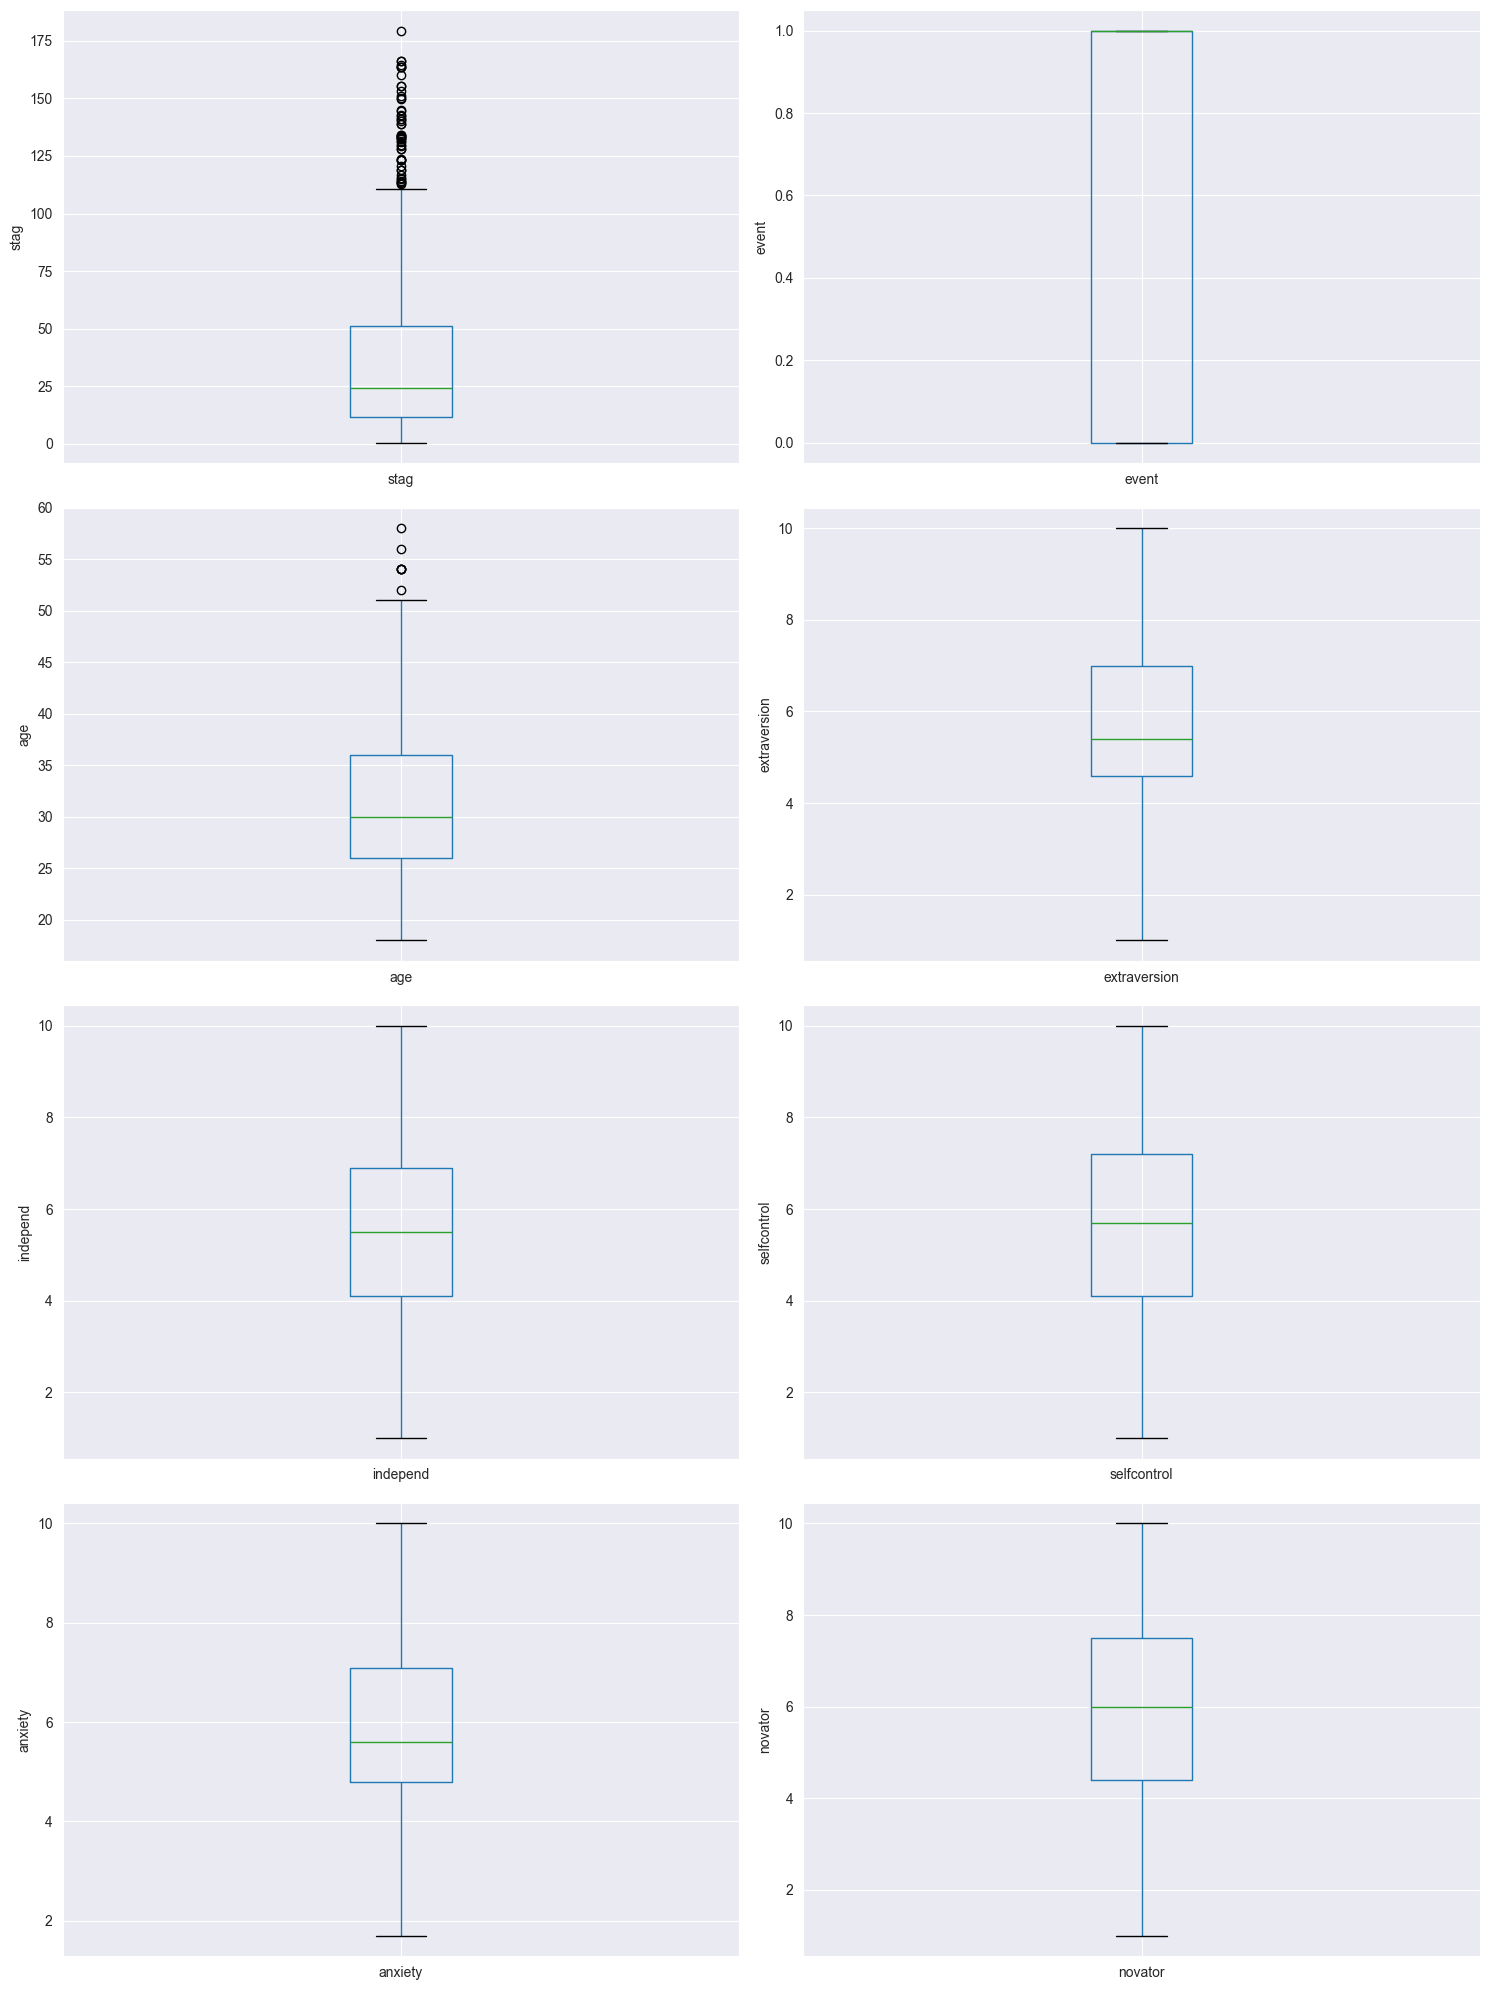

In [98]:
# plot boxplot to identify outliers in numerical variables
# Create a figure with a specified size
plt.figure(figsize=(15, 20))

# List of columns to plot
columns = ['stag', 'event', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

# Loop through the columns and create a subplot for each
for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    fig = df.boxplot(column=column)
    fig.set_title('')
    fig.set_ylabel(column)

# Show the plot
plt.tight_layout()
plt.show()

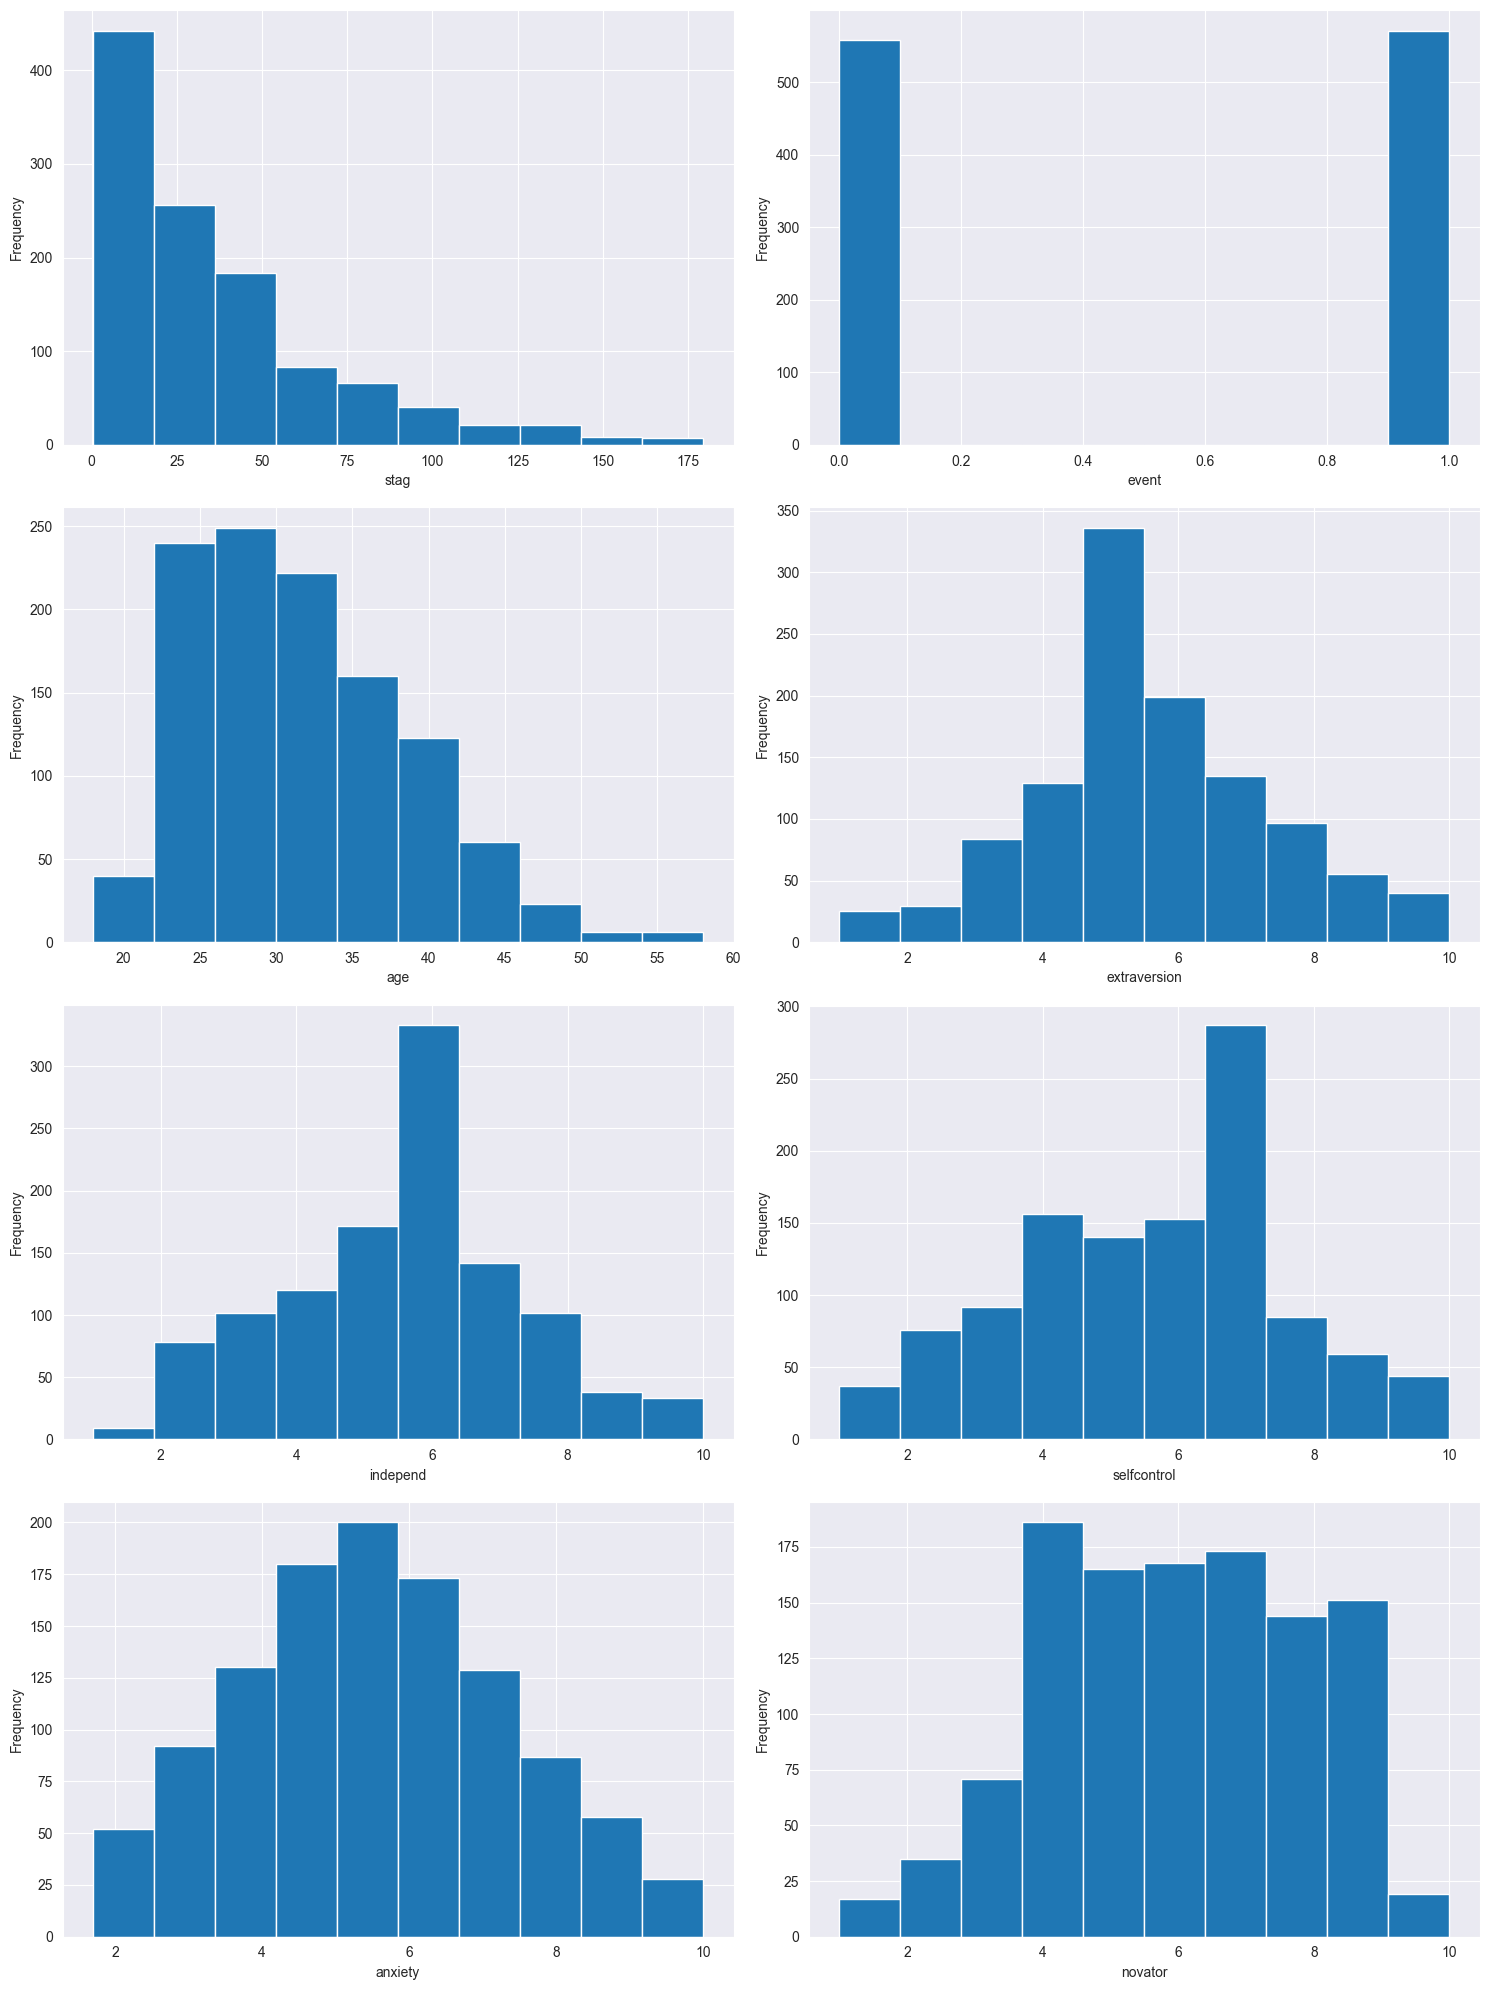

In [99]:
import matplotlib.pyplot as plt

# Create a figure with a specified size
plt.figure(figsize=(15, 20))

# List of columns to plot
columns = ['stag', 'event', 'age', 'extraversion', 'independ', 'selfcontrol', 'anxiety', 'novator']

# Loop through the columns and create a subplot for each
for i, column in enumerate(columns, 1):
    plt.subplot(4, 2, i)
    fig = df[column].hist(bins=10)
    fig.set_xlabel(column)
    fig.set_ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# find outliers for Rainfall variable

IQR = df.Rainfall.quantile(0.75) - df.Rainfall.quantile(0.25)
Lower_fence = df.Rainfall.quantile(0.25) - (IQR * 3)
Upper_fence = df.Rainfall.quantile(0.75) + (IQR * 3)
print('Rainfall outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence,
                                                                                   upperboundary=Upper_fence))